In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from io import StringIO


In [2]:
data = """Player,Country,Goals,Assists,Matches,Position,Age,Rating
Lionel Messi,Argentina,13,8,26,Forward,36,9.4
Cristiano Ronaldo,Portugal,9,3,22,Forward,38,8.7
Kylian Mbappe,France,12,5,23,Forward,24,9.1
Neymar Jr,Brazil,8,7,21,Forward,31,8.5
Luka Modric,Croatia,3,9,24,Midfielder,37,8.8
Kevin De Bruyne,Belgium,4,11,22,Midfielder,32,9.0
Robert Lewandowski,Poland,10,4,20,Forward,34,8.6
Harry Kane,England,11,3,24,Forward,29,8.7
Virgil van Dijk,Netherlands,2,1,22,Defender,32,8.9
Sadio Mane,Senegal,7,5,18,Forward,31,8.4
Vinicius Jr,Brazil,9,6,20,Forward,22,8.6
Erling Haaland,Norway,0,0,0,Forward,23,8.5
Pedri,Spain,2,6,18,Midfielder,20,8.3
Bukayo Saka,England,5,6,22,Midfielder,21,8.2
Gavi,Spain,1,5,16,Midfielder,19,8.1
Antoine Griezmann,France,7,8,23,Forward,32,8.6
Karim Benzema,France,6,4,15,Forward,35,8.5
Son Heung-min,South Korea,5,4,18,Forward,30,8.3
Mohamed Salah,Egypt,4,3,12,Forward,31,8.4
Riyad Mahrez,Algeria,4,5,16,Midfielder,32,8.0
"""

df = pd.read_csv(StringIO(data))

In [3]:
df["Goal_Contribution"] = df["Goals"] + df["Assists"]
df["Goals_Per_Match"] = (df["Goals"] / df["Matches"].replace(0, np.nan)).round(2)
df["Assists_Per_Match"] = (df["Assists"] / df["Matches"].replace(0, np.nan)).round(2)


In [4]:
print("=" * 55)
print("       🏆 WORLD CUP PLAYER STATS — SUMMARY")
print("=" * 55)
print(f"Total Players Tracked : {len(df)}")
print(f"Total Goals Scored    : {df['Goals'].sum()}")
print(f"Total Assists         : {df['Assists'].sum()}")
print(f"Avg Player Rating     : {df['Rating'].mean():.2f}")
print(f"Top Scorer            : {df.loc[df['Goals'].idxmax(), 'Player']} ({df['Goals'].max()} goals)")
print(f"Top Assist Provider   : {df.loc[df['Assists'].idxmax(), 'Player']} ({df['Assists'].max()} assists)")
print(f"Best Rated Player     : {df.loc[df['Rating'].idxmax(), 'Player']} ({df['Rating'].max()})")
print("=" * 55)


       🏆 WORLD CUP PLAYER STATS — SUMMARY
Total Players Tracked : 20
Total Goals Scored    : 122
Total Assists         : 103
Avg Player Rating     : 8.58
Top Scorer            : Lionel Messi (13 goals)
Top Assist Provider   : Kevin De Bruyne (11 assists)
Best Rated Player     : Lionel Messi (9.4)


C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


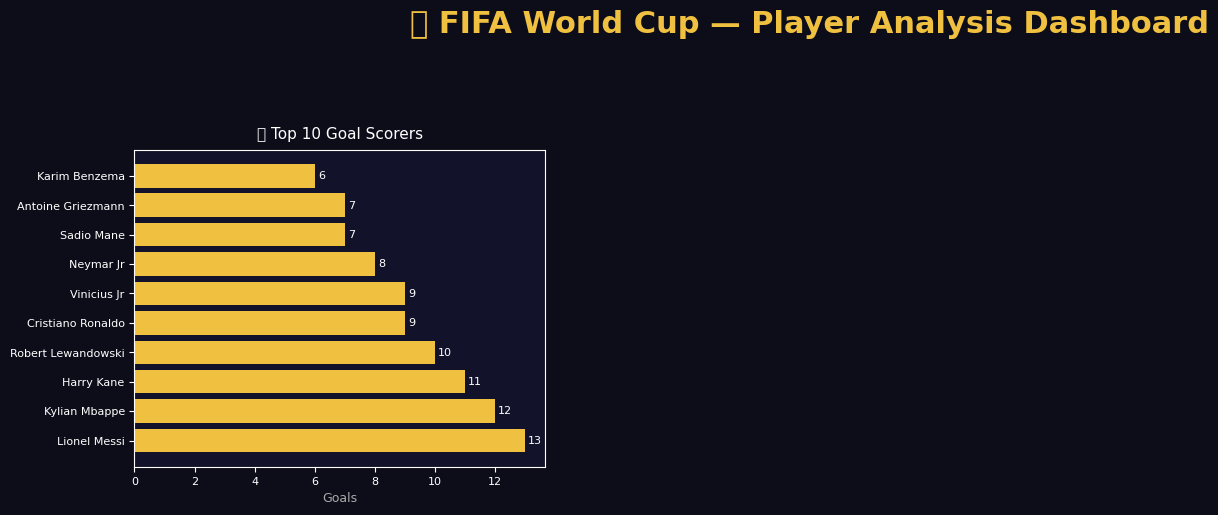

In [5]:
plt.style.use("dark_background")
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d0d1a")
fig.suptitle("🏆 FIFA World Cup — Player Analysis Dashboard",
             fontsize=22, fontweight="bold", color="#f0c040", y=0.98)

colors = ["#f0c040", "#e05c5c", "#5ce0a8", "#5ca8e0", "#c05ce0"]

# ── Chart 1: Top 10 Goal Scorers ──────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
top_scorers = df.nlargest(10, "Goals")
bars = ax1.barh(top_scorers["Player"], top_scorers["Goals"],
                color=colors[0], edgecolor="none")
ax1.set_facecolor("#12122a")
ax1.set_title("⚽ Top 10 Goal Scorers", color="white", fontsize=11, pad=8)
ax1.tick_params(colors="white", labelsize=8)
ax1.set_xlabel("Goals", color="#aaaaaa", fontsize=9)
for bar, val in zip(bars, top_scorers["Goals"]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", color="white", fontsize=8)